# Koopman Operator Inference Notebook

This notebook loads a pre-trained Koopman operator model combined with an autoencoder from a specified folder, recreates the dataset based on saved arguments, and performs inference. The model weights are loaded from `model.pkl`, and the configuration is read from `args.json`.

In [1]:
import json
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet
from utils.Viz import *
from utils.inference import *

# Set device
device = get_device()

Using the CPU


## Load Configuration

Load the saved `args.json` from the experiment folder to recreate the model and dataset configuration.

In [2]:
# Specify the folder path (modify this to your experiment folder)
folder_path = 'experiments/simple'  # Example folder from your training notebook

# Load args from JSON
args_json_path = os.path.join(folder_path, 'args.json')
if not os.path.isfile(args_json_path):
    raise FileNotFoundError(f"args.json not found in {folder_path}")

with open(args_json_path, 'r') as f:
    args_dict = json.load(f)

# Convert dictionary to argparse.Namespace
import argparse
args = argparse.Namespace(**args_dict)
print(f'Loaded arguments from {args_json_path}')

# Set seeds for reproducibility
set_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)

Loaded arguments from experiments/simple/args.json


## Recreate Dataset

Recreate the dataset using the `KoopmanDataHandler` with the loaded configuration.

In [3]:
# Configuration for data handler based on loaded args
config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize and prepare data
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get input size for model
input_size = preprocessed_data['Xtrain'].shape[-1]

print('Dataset loaded and preprocessed successfully.')
print(f'Processed data shapes - Train: {preprocessed_data["Xtrain"].shape}, Val: {preprocessed_data["Xval"].shape}, Test: {preprocessed_data["Xtest"].shape}')

100%|██████████| 500/500 [00:00<00:00, 16741.32it/s]

the shape of the data is torch.Size([500, 51, 3])
Processing dataset: simple
train_idx: 400, val_idx: 450
Processed data shapes - Train: torch.Size([400, 51, 3]), Val: torch.Size([50, 51, 3]), Test: torch.Size([50, 51, 3])
Dataset loaded and preprocessed successfully.
Processed data shapes - Train: torch.Size([400, 51, 3]), Val: torch.Size([50, 51, 3]), Test: torch.Size([50, 51, 3])



/Users/fmenol/Documents/GitHub/bio-koopman-autoencoder/data_handler.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/fmenol/Documents/GitHub/bio-koopman-autoencoder/data_handler.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/fmenol/Documents/GitHub/bio-koopman-autoencoder/data_handler.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtest = torch.tensor(Xtest, dtype=torch.float32

## Recreate Model

Recreate the autoencoder and Koopman operator model using the loaded arguments.

In [4]:
# Define autoencoder and Koopman operator
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

# Combine into a model
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet})
model = model.to(device)

## Load Pre-trained Model

Load the pre-trained model weights from `model.pkl`.

In [5]:
# Load model checkpoint
checkpoint_path = os.path.join(folder_path, 'model.pkl')
if not os.path.isfile(checkpoint_path):
    raise FileNotFoundError(f"model.pkl not found at {checkpoint_path}")

model.load_state_dict(torch.load(checkpoint_path))
model.eval()  # Set to evaluation mode
print(f'Model loaded from {checkpoint_path}')

RuntimeError: Error(s) in loading state_dict for ModuleDict:
	Missing key(s) in state_dict: "ae.encoder.0.net.0.weight", "ae.encoder.0.net.0.bias", "ae.encoder.0.net.2.weight", "ae.encoder.0.net.2.bias", "ae.encoder.0.net.4.weight", "ae.encoder.0.net.4.bias". 
	Unexpected key(s) in state_dict: "ae.encoder.net.0.weight", "ae.encoder.net.0.bias", "ae.encoder.net.2.weight", "ae.encoder.net.2.bias", "ae.encoder.net.4.weight", "ae.encoder.net.4.bias". 

## Inference

perform inference using the loaded model on a given data sample.

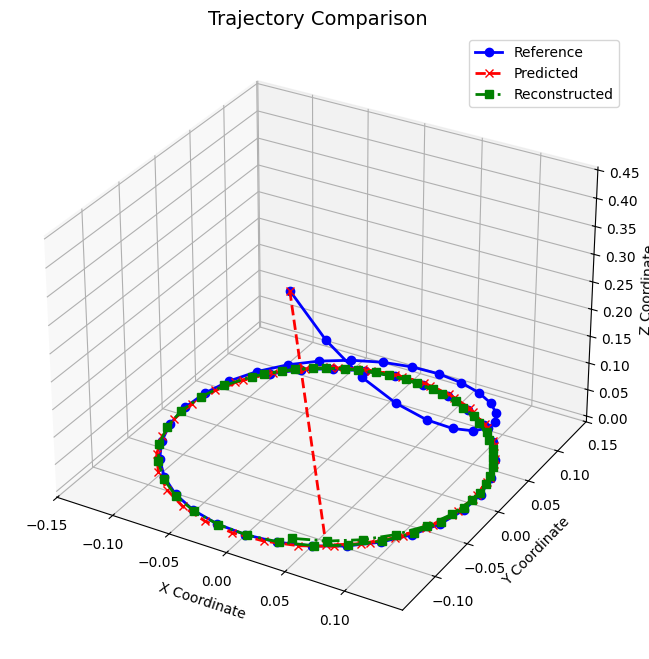

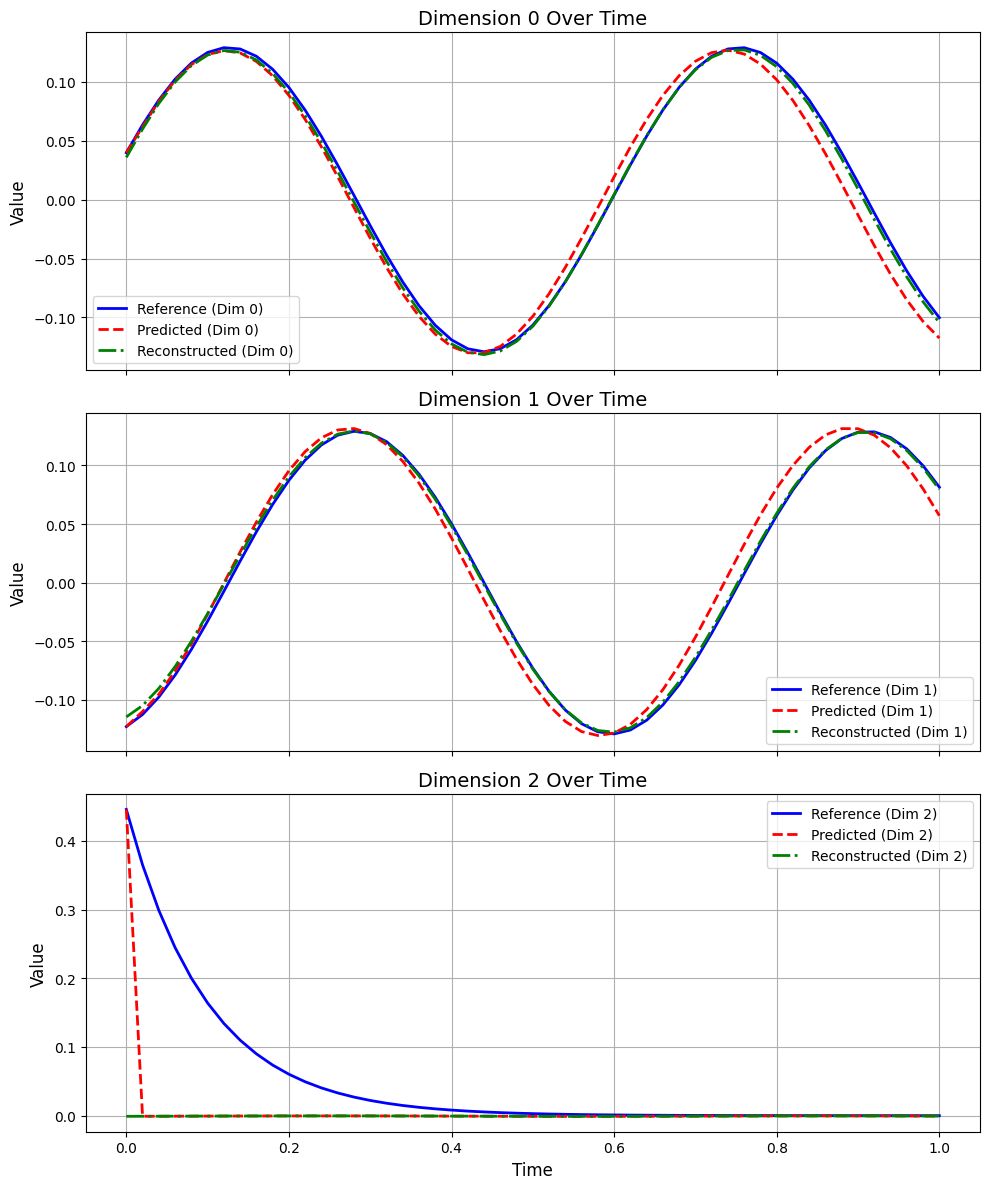

In [ ]:
# Get a test sample (e.g. 20th trajectory from test set)
traj = preprocessed_data["Xtest"][20].to(device)

# Call functions with distinct variable names for results
predicted_traj = predict_koopman_trajectory(model, traj[0], steps=50,device=device)
reconstructed_traj = reconstruct_trajectory(model, traj, device=device)


# Plot trajectories
plot_trajectories(traj, predicted_traj, reconstructed_traj, folder_path=folder_path, save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path, save=False)